In [11]:
from risk_experiment.symbolic_experiment.fit_probit import build_model, get_data
import pymc as pm
import arviz as az
from pathlib import Path

In [12]:
bids_folder = '/data/ds-symbolicrisk'
model_labels = [0, 1,2,3]

traces = {}

for model_label in model_labels:
    model = build_model(model_label)
    fn = Path(bids_folder) / 'derivatives' / 'risk_model' / 'psychophysical' / f'model{model_label}_samples.nc'

    idata = az.from_netcdf(fn)
    idata = idata.sel(draw=slice(None, None, 10))

    model.compute_log_likelihood(idata)

    traces['model' + str(model_label)] = idata

In [13]:
comparison = az.compare(traces)

/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaf

In [14]:
comparison[['elpd_loo', 'p_loo', 'weight', 'dse']].round(2).to_clipboard()

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

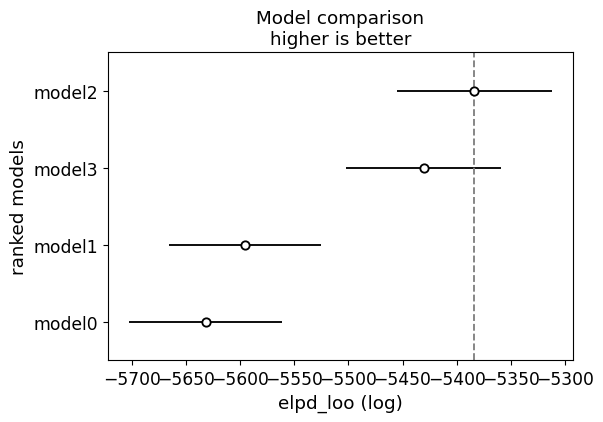

In [15]:
pm.plot_compare(comparison)

In [18]:
traces['model0'].posterior

<xarray.Dataset> Size: 96MB
Dimensions:                       (chain: 4, draw: 200,
                                   subject__factor_dim: 58, __obs__: 14848)
Coordinates:
  * chain                         (chain) int64 32B 0 1 2 3
  * draw                          (draw) int64 2kB 0 10 20 30 ... 1970 1980 1990
  * subject__factor_dim           (subject__factor_dim) <U3 696B '100' ... '99'
  * __obs__                       (__obs__) int64 119kB 0 1 2 ... 14846 14847
Data variables:
    Intercept                     (chain, draw) float64 6kB ...
    log_risky_safe                (chain, draw) float64 6kB ...
    1|subject_sigma               (chain, draw) float64 6kB ...
    log_risky_safe|subject_sigma  (chain, draw) float64 6kB ...
    1|subject                     (chain, draw, subject__factor_dim) float64 371kB ...
    log_risky_safe|subject        (chain, draw, subject__factor_dim) float64 371kB ...
    p                             (chain, draw, __obs__) float64 95MB 0.9416 ...
Attributes:
    created_at:                  2025-04-15T12:22:21.664620+00:00
    arviz_version:               0.20.0
    inference_library:           pymc
    inference_library_version:   5.17.0
    sampling_time:               445.23779678344727
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.14.0

In [19]:
traces['model3'].posterior

<xarray.Dataset> Size: 99MB
Dimensions:                                     (chain: 4, draw: 200,
                                                 C(n_safe_bin)_dim: 4,
                                                 log_risky_safe:C(n_safe_bin)_dim: 4,
                                                 subject__factor_dim: 58,
                                                 C(n_safe_bin)__expr_dim: 4,
                                                 log_risky_safe:C(n_safe_bin)__expr_dim: 4,
                                                 __obs__: 14848)
Coordinates:
  * chain                                       (chain) int64 32B 0 1 2 3
  * draw                                        (draw) int64 2kB 0 10 ... 1990
  * C(n_safe_bin)_dim                           (C(n_safe_bin)_dim) <U5 80B '...
  * log_risky_safe:C(n_safe_bin)_dim            (log_risky_safe:C(n_safe_bin)_dim) <U5 80B ...
  * subject__factor_dim                         (subject__factor_dim) <U3 696B ...
  * C(n_safe_bin)__expr_dim                     (C(n_safe_bin)__expr_dim) <U5 80B ...
  * log_risky_safe:C(n_safe_bin)__expr_dim      (log_risky_safe:C(n_safe_bin)__expr_dim) <U5 80B ...
  * __obs__                                     (__obs__) int64 119kB 0 ... 1...
Data variables: (12/13)
    Intercept                                   (chain, draw) float64 6kB ...
    log_risky_safe                              (chain, draw) float64 6kB ...
    C(n_safe_bin)                               (chain, draw, C(n_safe_bin)_dim) float64 26kB ...
    log_risky_safe:C(n_safe_bin)                (chain, draw, log_risky_safe:C(n_safe_bin)_dim) float64 26kB ...
    1|subject_sigma                             (chain, draw) float64 6kB ...
    log_risky_safe|subject_sigma                (chain, draw) float64 6kB ...
    ...                                          ...
    log_risky_safe:C(n_safe_bin)|subject_sigma  (chain, draw, log_risky_safe:C(n_safe_bin)__expr_dim) float64 26kB ...
    1|subject                                   (chain, draw, subject__factor_dim) float64 371kB ...
    log_risky_safe|subject                      (chain, draw, subject__factor_dim) float64 371kB ...
    C(n_safe_bin)|subject                       (chain, draw, C(n_safe_bin)__expr_dim, subject__factor_dim) float64 1MB ...
    log_risky_safe:C(n_safe_bin)|subject        (chain, draw, log_risky_safe:C(n_safe_bin)__expr_dim, subject__factor_dim) float64 1MB ...
    p                                           (chain, draw, __obs__) float64 95MB ...
Attributes:
    created_at:                  2025-06-20T14:50:11.494777+00:00
    arviz_version:               0.20.0
    inference_library:           pymc
    inference_library_version:   5.17.0
    sampling_time:               1035.497682094574
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.14.0